## 19.4. Multi-Fidelity Hyperparameter Optimization

In [2]:
from collections import defaultdict
import numpy as np
from scipy import stats
from d2l import torch as d2l

d2l.set_figsize()

### 19.4.1. Successive Halving

In [3]:
class SuccessiveHalvingScheduler(d2l.HPOScheduler): #@save
  def __init__(self, searcher, eta, r_min, r_max, prefact=1):
    self.save_hyperparameters()
    # Compute K, which is later used to determine the number of configurations
    self.K = int(np.log(r_max / r_min) / np.log(eta))
    # Define the rung
    self.rung_levels = [r_min * eta ** k for k in range(self.K + 1)]
    if r_max not in self.rung_levels:
      # The final rung should be r_max
      self.rung_levels.append(r_max)
      self.K += 1
    # Bookkeeping
    self.observed_error_at_rungs = defaultdict(list)
    self.all_observed_error_at_rungs = defaultdict(list)
    # Our processing queue
    self.queue = []

In [4]:
@d2l.add_to_class(SuccessiveHalvingScheduler) #@save
def suggest(self):
  if len(self.queue) == 0:
    # Start a new round of succesive halving
    # Number of configurations for the first tung
    n0 = int(self.prefact * self.eta ** self.K)
    for _ in range(n0):
      config = self.searcher.sample_configuration()
      config["max_epochs"] = self.r_min # r = r_min
      self.queue.append(config)
  # return an elem from the queue
  return self.queue.pop()

In [5]:
@d2l.add_to_class(SuccessiveHalvingScheduler) #@save
def update(self, config: dict, error: float, info=None):
  ri = int(config["max_epochs"]) # Rung r_i
  # Update our searcher, e.g. if we use Bayesian optimization later
  self.searcher.update(config, error, additional_info=info)
  self.all_observed_error_at_rungs[ri].append((config, error))
  if ri < self.r_max:
    # Bookkeeping
    self.observed_error_at_rungs[ri].append((config, error))
    # Determine how many configurations should be evaluated on this rung
    ki = self.K - self.rung_levels.index(ri)
    ni = int(self.prefact * self.eta ** ki)
    # If we observed all configuration on this rung r_i, we estimate the
    # top 1 / eta configuration, add them to queue and promote them for
    # the next rung r_{i+1}
    if len(self.observed_error_at_rungs[ri]) >= ni:
      kiplus1= ki - 1
      niplus1 = int(self.prefact * self.eta ** kiplus1)
      best_performing_configurations  = self.get_top_n_configurations(
        rung_level=ri, n=niplus1
      )
      riplus1 = self.rung_levels[self.K - kiplus1] #r_{i+1}
      # Queue may not be empty: insert new entries at the beginning
      self.queue = [
        dict(config, max_epochs=riplus1)
        for config in best_performing_configurations
      ] + self.queue
      self.observed_error_at_rungs[ri] = []

In [6]:
@d2l.add_to_class(SuccessiveHalvingScheduler) #@save
def get_top_n_configurations(self, rung_level, n):
  rung = self.observed_error_at_rungs[rung_level]
  if not rung:
    return []
  sorted_rung = sorted(rung, key=lambda x: x[1])
  return [x[0] for x in sorted_rung[:n]]

In [7]:
min_number_of_epochs = 2
max_number_of_epochs = 10
eta = 2
num_gpus=1

config_space = {
  "learning_rate": stats.loguniform(1e-2, 1),
  "batch_size": stats.randint(32, 256)
}
initial_config = {
  "learning_rate": 0.1,
  "batch_size": 128,
}

RuntimeError: [enforce fail at C:\actions-runner\_work\pytorch\pytorch\builder\windows\pytorch\c10\core\impl\alloc_cpu.cpp:72] data. DefaultCPUAllocator: not enough memory: you tried to allocate 1260672 bytes.

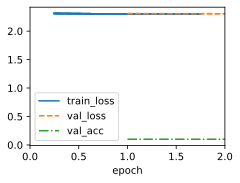

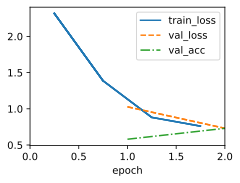

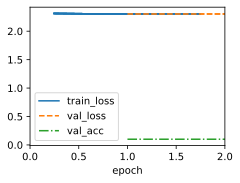

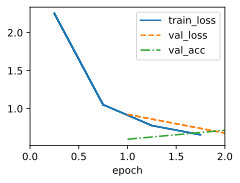

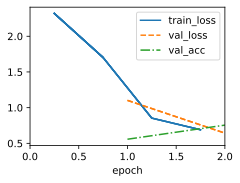

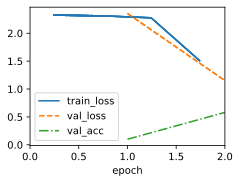

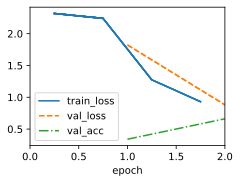

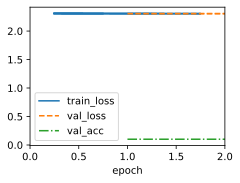

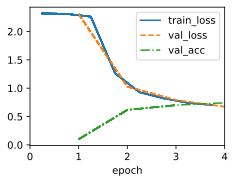

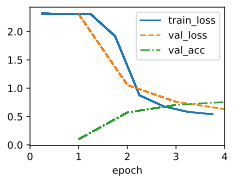

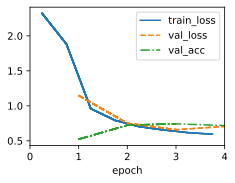

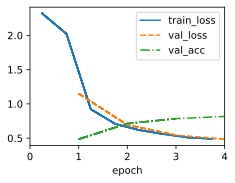

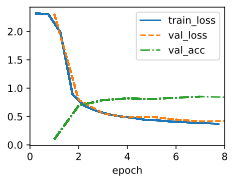

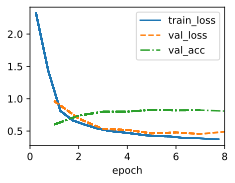

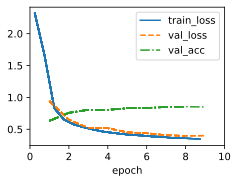

In [8]:
searcher = d2l.RandomSearcher(config_space, initial_config=initial_config)
scheduler = SuccessiveHalvingScheduler(
  searcher=searcher,
  eta=eta,
  r_min=min_number_of_epochs,
  r_max=max_number_of_epochs,
)
tuner = d2l.HPOTuner(
  scheduler=scheduler,
  objective=d2l.hpo_objective_lenet,
)
tuner.run(number_of_trials=30)

Text(0.5, 0, 'epochs')

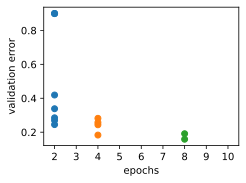

In [10]:
for rung_index, rung in scheduler.all_observed_error_at_rungs.items():
  errors = [xi[1] for xi in rung]
  d2l.plt.scatter([rung_index] * len(errors), errors)
d2l.plt.xlim(min_number_of_epochs - 0.5, max_number_of_epochs + 0.5)
d2l.plt.xticks(
  np.arange(min_number_of_epochs, max_number_of_epochs + 1),
  np.arange(min_number_of_epochs, max_number_of_epochs + 1)
)
d2l.plt.ylabel("validation error")
d2l.plt.xlabel("epochs")